# P2 — Features & Taxonomy

This notebook is the platform's feature-level verification & validation surface
(Phase 6, NB-01). It groups every `monthly_features` column into the
fast / slow / agency / untagged tiers the platform declares in
`config/platform_settings.yaml`, shows coverage per tier, flags any feature
whose observed range is domain-impossible, re-runs the audit-item-A4
level-discontinuity guard against the agency-tier raw series, and ranks how far
each lean feature's current-era distribution has moved from the pre-2021 fitted
window. It is not in the weekly scoring path — it is opened when something needs
checking, not on every run.

**Run `python scripts/build_platform_data.py` first if the `monthly_features` or
`monthly_raw` checkpoints are missing.**

In [1]:
%matplotlib inline
import logging

logging.basicConfig(level=logging.INFO)

from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.plotting import data as pdata
from trading_crab_lib.platform.plotting import drift as pdrift
from trading_crab_lib.platform.plotting import features as pfeatures

cfg = load_platform_config()
# Never display cfg directly (T-06-01) -- it carries a live FRED_API_KEY.
# redacted_config() replaces every *api_key value before anything is shown.
print("platform config sections:", sorted(pplot.redacted_config(cfg).keys()))

platform config sections: ['allocation', 'backtest', 'cv', 'data', 'fred_daily', 'fred_monthly', 'fred_vintage', 'holdout', 'labeling', 'macrotrends_monthly', 'multpl_monthly', 'paid_providers', 'registry', 'report', 'splice', 'taxonomy', 'tiingo', 'tripwire', 'universe']


## Why there is no causal-vs-centered panel here

The legacy quarterly pipeline (ADR #1) maintains two parallel feature files —
centered smoothing for clustering, causal smoothing for supervised learning —
and its notebook 02 carries a panel comparing them. **The platform did not
inherit that split, and this notebook deliberately carries no such panel.**

Platform features are **causal-only by construction**: `transforms_monthly.py`
contains zero occurrences of `center`, `centered`, or `causal`. There is no
centered variant to overlay because none is ever built.

More than that, a centered variant is **architecturally forbidden**.
`honesty/gating.py` defines
`FORBIDDEN_CENTERED_SUFFIXES = ("_centered", "_c5", "_zerophase")` and its
`assert_causal_features` guard raises on sight of any column carrying one. Were
this notebook to helpfully synthesise a centered series so the comparison panel
could exist, it would be manufacturing exactly the artifact the platform's own
gating rail is built to reject.

The only intentional hindsight anywhere in the system is the **L1 labeler's
deliberate non-causal batch DP-decode** — a whole-history dynamic-programming
decode that is allowed to see the future *when producing reference labels*, and
which the walk-forward's filtered path is then measured against. That hindsight
lives in the labeler, never in the features.

So the absence of a causal-vs-centered panel here is a stated architectural
fact, not a missing feature.

In [2]:
REBUILD_HINT = "python scripts/build_platform_data.py"

monthly_features = pplot.load_platform_checkpoint("monthly_features", rebuild_hint=REBUILD_HINT)
monthly_raw = pplot.load_platform_checkpoint("monthly_raw", rebuild_hint=REBUILD_HINT)

for name, frame in (("monthly_features", monthly_features), ("monthly_raw", monthly_raw)):
    print(f"{name}: shape={frame.shape}  index {frame.index.min()} -> {frame.index.max()}")

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_features  (708 rows × 53 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_raw  (776 rows × 45 cols)


monthly_features: shape=(708, 53)  index 1962-01-31 00:00:00 -> 2020-12-31 00:00:00
monthly_raw: shape=(776, 45)  index 1962-01-31 00:00:00 -> 2026-08-31 00:00:00


## Coverage, grouped by taxonomy tier

`taxonomy.classify_feature` is the single source of tier membership — the tiers
below are read from it, never re-derived from a local list. Columns it does not
classify are grouped as **untagged**: the raw pass-through columns (the ETF
universe and the intermediate splice series).

**What to look for, in priority order:**

1. **A lean-tier feature (`fast` or `slow`) whose coverage starts unexpectedly
   late.** These 13 columns are the full-history labeling set — a late start
   here truncates the span the labeler can fit on. `fred_vix` starting 1990 and
   `gold`/`oil` starting 1985 are known and expected; anything else is not.
2. **Any row that goes dark before the right edge**, at any tier — a series that
   silently stopped updating still passes a row/column count check and only
   shows up here.
3. **Agency-tier and untagged gaps are lower priority.** Agency features are
   "used sparingly" by design (design §9) and are excluded from the lean set;
   untagged columns are raw pass-through, and the ETF universe genuinely does
   not exist before the 1990s-2000s.

{'fast': 10, 'slow': 3, 'agency': 5, 'untagged': 35} -> 53 columns


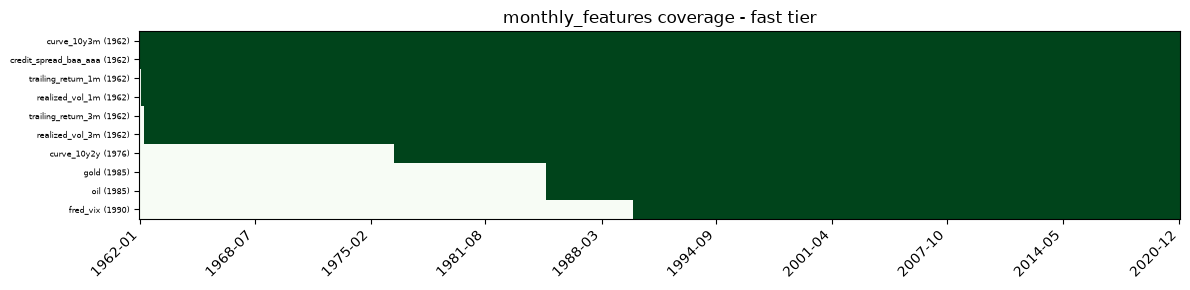

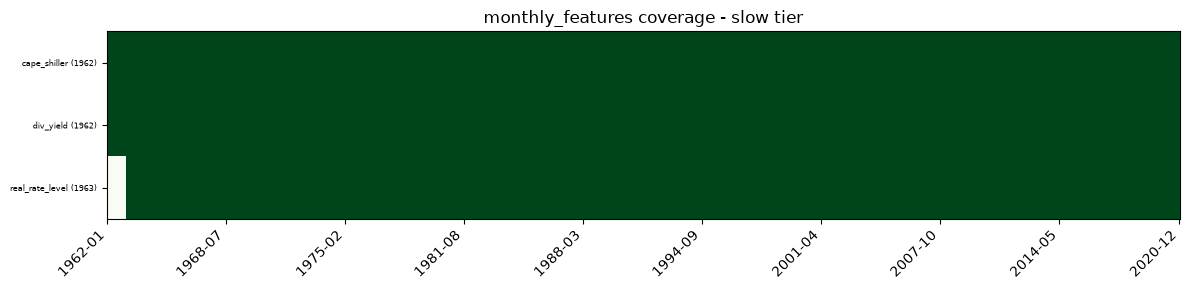

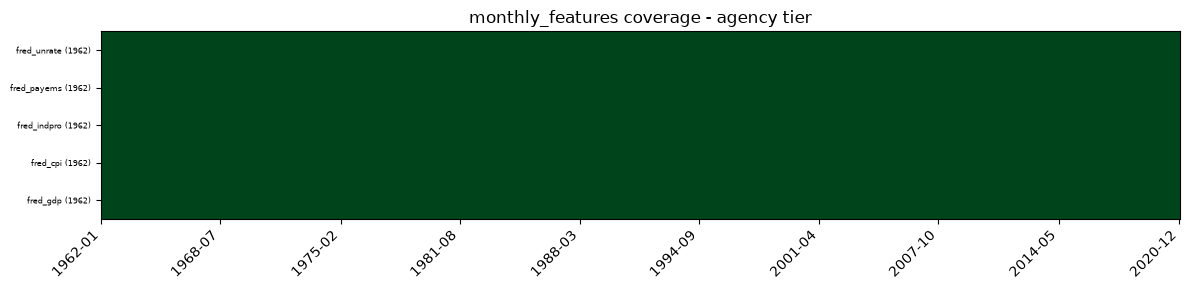

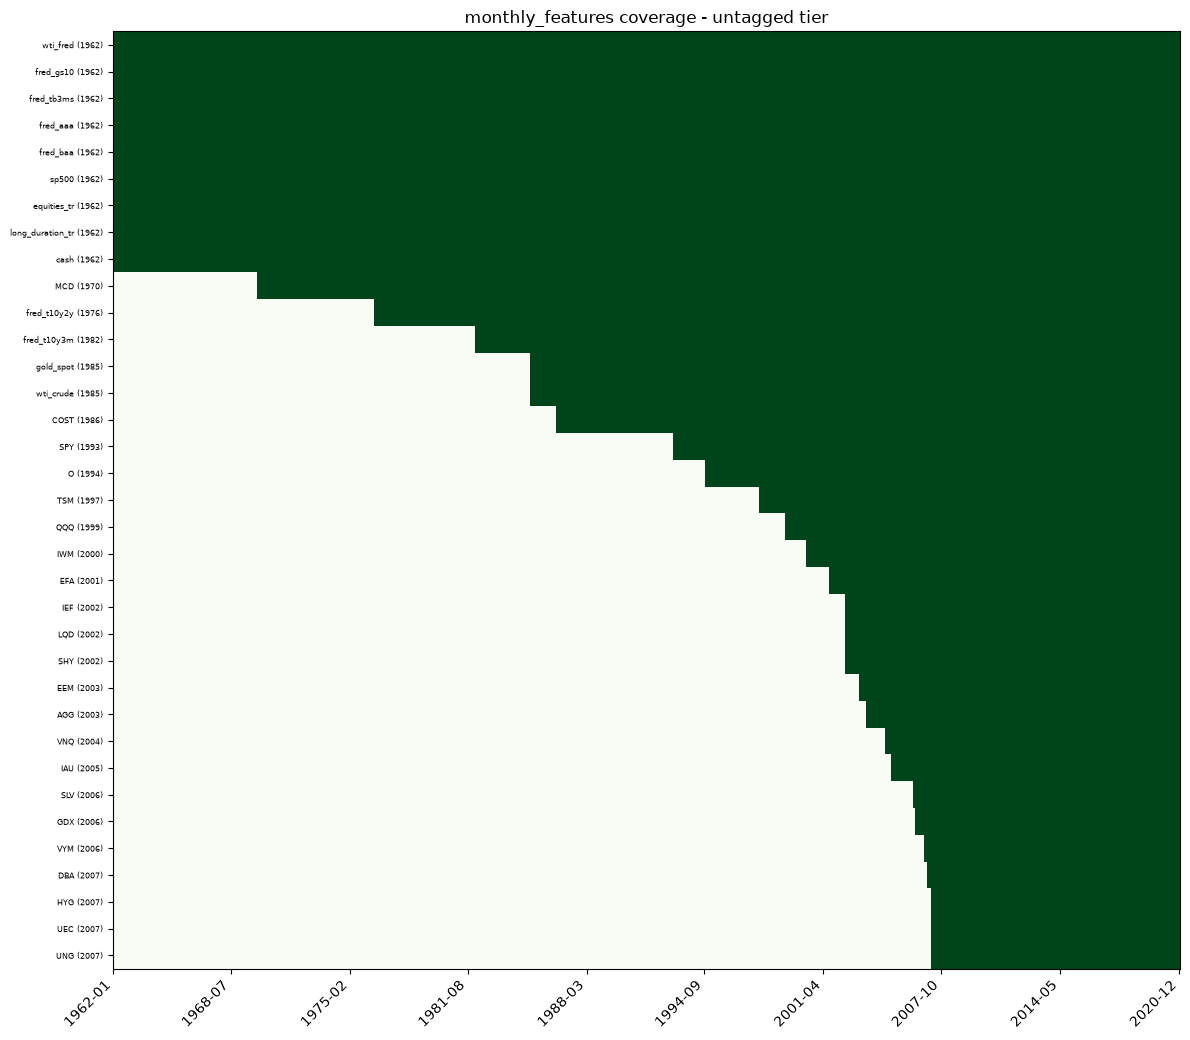

In [3]:
tiers = pfeatures.tier_frames(monthly_features, cfg)
print({name: frame.shape[1] for name, frame in tiers.items()}, "->", monthly_features.shape[1], "columns")

for tier_name, frame in tiers.items():
    if frame.shape[1] == 0:
        print(f"(tier '{tier_name}' has no members - coverage grid skipped)")
        continue
    pdata.plot_coverage_timeline(frame, title=f"monthly_features coverage - {tier_name} tier")

## Observed ranges, per feature

One row per column: its tier, how many observations it carries, the span it
covers, and its observed min / max / mean / std. The two charts below render the
lean tiers on a **symmetric-log** x-axis — a single tier spans
`realized_vol_1m` near 8e-05 alongside `gold` near 2000, and on a linear axis
every small-valued feature would collapse onto the zero line.

In [4]:
range_table = pfeatures.feature_range_table(monthly_features, cfg)
print(range_table.to_string())

                  feature      tier  n_obs first_valid last_valid           min            max          mean            std
0                fred_cpi    agency    707  1962-02-28 2020-12-31     30.040000     259.165654    133.265859      73.628257
1                fred_gdp    agency    707  1962-02-28 2020-12-31   3758.147000   20305.437908  10926.675580    4911.288878
2             fred_indpro    agency    708  1962-01-31 2020-12-31    114.199131     360.006214    226.042812      67.423639
3             fred_payems    agency    708  1962-01-31 2020-12-31  54434.000000  129138.767350  93563.026219   21632.424951
4             fred_unrate    agency    708  1962-01-31 2020-12-31      3.321405      15.010355      6.137322       1.755409
5   credit_spread_baa_aaa      fast    708  1962-01-31 2020-12-31      0.320000       3.380000      1.021017       0.441912
6             curve_10y2y      fast    535  1976-06-30 2020-12-31     -2.010000       2.840000      0.925402       0.904721
7       

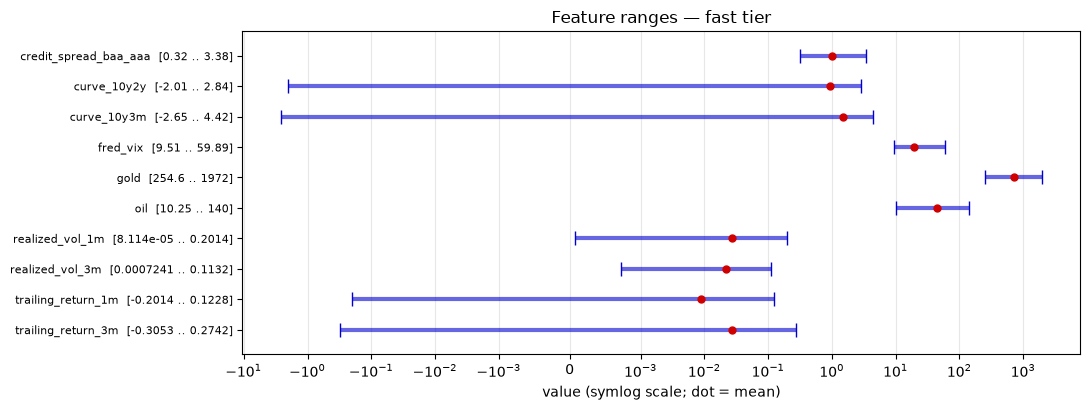

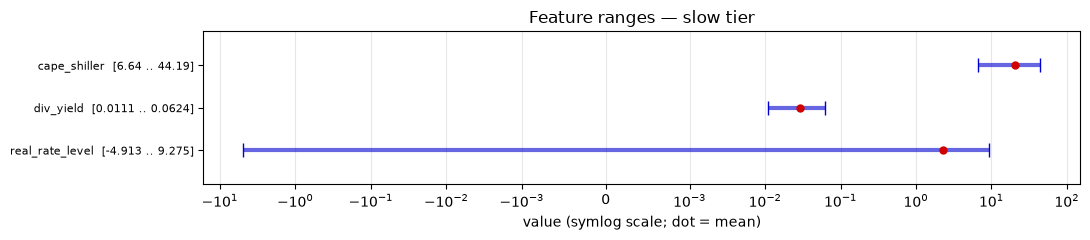

In [5]:
pfeatures.plot_feature_ranges(range_table, tier="fast")
pfeatures.plot_feature_ranges(range_table, tier="slow");

## Quality gate — impossible values and level discontinuities

Two checks run here, **before** anything further is rendered, because a chart
drawn over an impossible value looks complete and tells you nothing.

**`assert_feature_ranges_plausible`** compares each named feature's observed
range against a bound that comes from economics, not from the data: the VIX
cannot be zero or negative, a realized volatility cannot be negative, Baa-Aaa
does not go meaningfully below zero, a P/E ratio and a spot commodity price are
positive, and the S&P 500 dividend yield has never been negative nor exceeded
15%. It collects every violation and raises once. This is the check class that
drift-against-baseline structurally cannot replace: the percent-vs-decimal yield
defect that compounded a total-return index to 1e128 was **uniform across the
whole 1962-2026 span**, so it showed zero drift against itself.

**`check_agency_level_discontinuities`** is the regression guard for audit item
**A4**. ALFRED point-in-time vintages of a *rebased* index are not
level-comparable across rebasings, which put two artificial ~3x jumps into
`fred_cpi` (1970-12 -> 1971-01 and 1988-01 -> 1988-02) and propagated into
`real_rate_level`, a defining feature of two labeler states holding 64.3% of
occupancy. That defect is fixed. **An empty dict below means it is still
fixed** — the guard re-runs on every open rather than trusting a one-time repair.

In [6]:
verdict = pfeatures.assert_feature_ranges_plausible(range_table)
print(verdict.to_string())

clean = pfeatures.check_agency_level_discontinuities(monthly_raw, columns=("fred_cpi",))
print("\nA4 level-discontinuity guard:", clean, "(empty dict == still fixed)")

                 feature         bound                observed verdict
0               fred_vix           > 0                min=9.51    pass
1        realized_vol_1m          >= 0           min=8.114e-05    pass
2        realized_vol_3m          >= 0         min=0.000724055    pass
3  credit_spread_baa_aaa     >= -0.005                min=0.32    pass
4           cape_shiller           > 0                min=6.64    pass
5                   gold           > 0               min=254.6    pass
6                    oil           > 0               min=10.25    pass
7              div_yield  in [0, 0.15]  min=0.0111, max=0.0624    pass

A4 level-discontinuity guard: {} (empty dict == still fixed)


## Full-span drift — crossing the holdout fence to LOOK, never to fit

**This cell reads post-2020 data. Everything above it does not.**

Per D-06 the honesty fence is on *fitting*, not on *looking*: model-fitting
paths use the default dev checkpoint manager, which structurally cannot reach
the holdout tree, while `load_full_span_checkpoint` is the explicit, visible
opt-in that concatenates dev + holdout. The plausibility and quality checks
above deliberately run on the **dev** frame only — a gate that can stop the
notebook must not be evaluated against data the fitting side never saw.

The baseline is the **pre-2021 fitted window**, not a rolling trailing window
(D-09). A rolling baseline decays alongside the feature it is measuring, so
gradual decay never trips it — which is precisely the failure this check exists
to catch (the motivating case: a feature that was predictive and quietly stopped
being predictive).

> **D-07:** any observation in this panel that changes a decision must be
> recorded, with its date, in `.planning/POST-2020-OBSERVATIONS.md`. Once you
> have seen post-2020 behavior it cannot be un-seen; the record is what keeps
> the influence traceable, and it is what a deflated-Sharpe denominator would
> need.

In [7]:
from trading_crab_lib.platform import taxonomy
from trading_crab_lib.platform.honesty.holdout import DEFAULT_HOLDOUT_CUTOFF

full_features = pplot.load_full_span_checkpoint("monthly_features", rebuild_hint=REBUILD_HINT)
print(f"full span: shape={full_features.shape}  index {full_features.index.min()} -> {full_features.index.max()}")

lean_cols = sorted(taxonomy.lean_feature_set(cfg) & set(full_features.columns))
print(f"{len(lean_cols)} lean (fast + slow) columns:", lean_cols)

drift_df = pdrift.drift_report(full_features, lean_cols, cutoff=DEFAULT_HOLDOUT_CUTOFF)
print(drift_df.to_string())

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_features  (708 rows × 53 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_features  (68 rows × 53 cols)


INFO:trading_crab_lib.platform.honesty.holdout:load_full_span: monthly_features -> 708 dev rows (<=2020-12-31) + 68 holdout rows (>2020-12-31) = 776


full span: shape=(776, 53)  index 1962-01-31 00:00:00 -> 2026-08-31 00:00:00
13 lean (fast + slow) columns: ['cape_shiller', 'credit_spread_baa_aaa', 'curve_10y2y', 'curve_10y3m', 'div_yield', 'fred_vix', 'gold', 'oil', 'real_rate_level', 'realized_vol_1m', 'realized_vol_3m', 'trailing_return_1m', 'trailing_return_3m']
                   column  n_baseline  n_current  baseline_mean  baseline_std  current_mean  standardized_mean_shift  ks_statistic     ks_pvalue  pct_beyond_2sigma   flag
0                    gold         431         68     722.873527    481.821386   2552.255294                 3.796805      0.948956  1.079625e-64           0.970588   True
1            cape_shiller         708         68      20.609675      8.078788     34.496324                 1.718902      0.832752  9.611474e-47           0.367647   True
2               div_yield         708         66       0.029025      0.011418      0.014044                -1.312062      0.864792  1.332696e-50           0.000000   

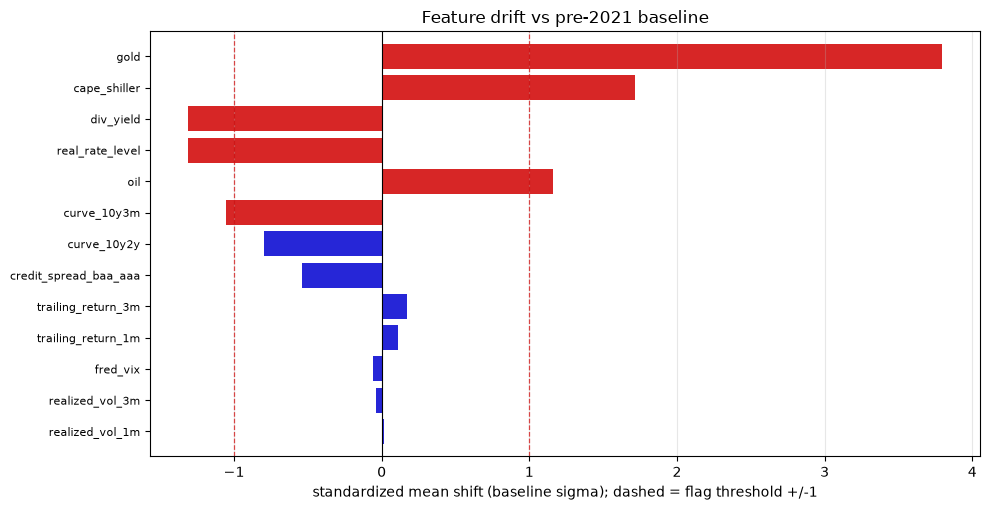

In [8]:
pfeatures.plot_drift_summary(drift_df);

## What you just checked

1. **Coverage by tier** — does any lean-tier (`fast`/`slow`) feature start later
   than expected, and does any series stop updating before the right edge?
2. **Observed ranges** — does any feature's span look wrong for what it claims
   to measure, even where it stayed inside its coded bound?
3. **The plausibility gate** — every named feature passed its domain bound, or
   the notebook stopped above with a `ValueError` naming the feature and the
   bound it violated.
4. **The A4 guard** — an empty dict means the `fred_cpi` ALFRED rebasing
   discontinuity has not regressed.
5. **Drift** — which lean features have moved furthest from the window the model
   was fitted on. A flagged feature is not automatically broken; it is a
   question ("is the world still the one this model learned?"), and if the
   answer changes a decision, it belongs in `.planning/POST-2020-OBSERVATIONS.md`.

**This notebook carries no operator sign-off and no per-run gate.** The cold-start
human decision is P3's exclusive responsibility (D-15); P2 is a periodic
verification & validation surface. It also sweeps no hyperparameter and selects
no features — it renders coverage, ranges, and quality for the shipped taxonomy
and the shipped feature set only (D-14's no-sweep discipline extended to feature
selection).